<a href="https://colab.research.google.com/github/LakshmiSri-ctrl/hackathon-practice/blob/main/Quant_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Force-update the library to the newest version to fix the 'delisted' error
!pip install --upgrade yfinance

Enter the Stock Symbol (e.g., SBIN, TCS, TATAMOTORS): TCS


[*********************100%***********************]  1 of 1 completed

🔄 Analyzing TCS.NS on the NSE...

🇮🇳 INDIAN MARKET ANALYSIS: TCS.NS
💰 TODAY'S CLOSE: ₹2581.50
🚀 AI PREDICTION (TOMORROW): ₹2583.15
📈 SIGNAL: BULLISH (+₹1.65 | +0.06%)



/tmp/ipykernel_3034/1891266930.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(df['Close'].iloc[-1])
/tmp/ipykernel_3034/1891266930.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_price = float(prediction)


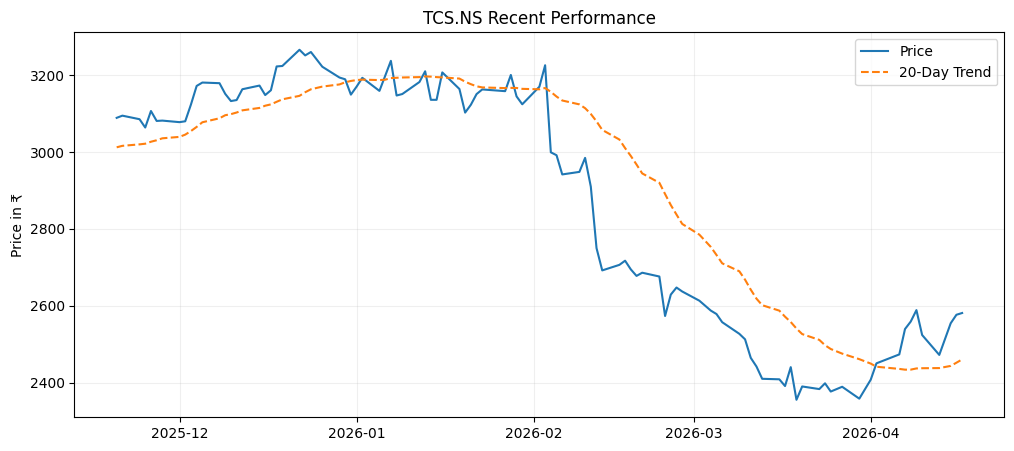

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- STEP 1: USER INPUT ---
stock_name = input("Enter the Stock Symbol (e.g., SBIN, TCS, TATAMOTORS): ").strip().upper()
ticker = f"{stock_name}.NS"

print(f"🔄 Analyzing {ticker} on the NSE...")

# --- STEP 2: DOWNLOAD DATA ---
df = yf.download(ticker, period="2y", interval="1d", auto_adjust=True)

if df.empty:
    print(f"⚠️ NSE not found for {stock_name}. Trying BSE...")
    ticker = f"{stock_name}.BO"
    df = yf.download(ticker, period="2y", interval="1d", auto_adjust=True)

if df.empty:
    print(f"❌ Could not find '{stock_name}' on NSE or BSE.")
else:
    # --- STEP 3: FEATURE ENGINEERING ---
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df = df.dropna().copy()

    # --- STEP 4: AI PREPARATION ---
    df['Target'] = df['Close'].shift(-1)
    latest_row = df.tail(1).copy()
    train_df = df.dropna()

    X = train_df[['Close', 'MA20', 'MA50']].values
    y = train_df['Target'].values

    # --- STEP 5: TRAIN THE AI ---
    model = LinearRegression()
    model.fit(X, y)

    # --- STEP 6: PREDICTION ---
    current_inputs = latest_row[['Close', 'MA20', 'MA50']].values
    prediction = model.predict(current_inputs)

    current_price = float(df['Close'].iloc[-1])
    predicted_price = float(prediction)

    # --- STEP 7: DISPLAY RESULTS (With Percentage Edit) ---
    change_rupees = predicted_price - current_price
    percent_change = (change_rupees / current_price) * 100

    print("\n" + "="*45)
    print(f"🇮🇳 INDIAN MARKET ANALYSIS: {ticker}")
    print(f"💰 TODAY'S CLOSE: ₹{current_price:.2f}")
    print(f"🚀 AI PREDICTION (TOMORROW): ₹{predicted_price:.2f}")

    if change_rupees > 0:
        print(f"📈 SIGNAL: BULLISH (+₹{change_rupees:.2f} | +{percent_change:.2f}%)")
    else:
        print(f"📉 SIGNAL: BEARISH (-₹{abs(change_rupees):.2f} | {percent_change:.2f}%)")
    print("="*45)

    # --- STEP 8: VISUAL CHART ---
    plt.figure(figsize=(12, 5))
    plt.plot(df.index[-100:], df['Close'].tail(100), label='Price', color='#1f77b4')
    plt.plot(df.index[-100:], df['MA20'].tail(100), label='20-Day Trend', color='#ff7f0e', linestyle='--')
    plt.title(f"{ticker} Recent Performance")
    plt.ylabel("Price in ₹")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()